# Laboratorio 03 — Modelos de Regresión Lineal
## CC3074 – Minería de Datos | Universidad del Valle de Guatemala

**Integrantes del grupo:**
- Erick Guerra 23208
-
-

**Dataset:** House Prices: Advanced Regression Techniques (Kaggle)


---
## Actividad 1 — Descarga y carga del conjunto de datos

In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Semilla global para reproducibilidad (Actividad 6)
SEED = 42
np.random.seed(SEED)

print('Librerías importadas ✅')

Librerías importadas ✅


Los archivos descargados de Kaggle son:
- `train.csv` — dataset principal con variable respuesta `SalePrice` (1,460 registros)
- `test.csv` — dataset sin variable respuesta, usado para submissions en Kaggle
- `data_description.txt` — diccionario de variables
- `sample_submission.csv` — formato de entrega para Kaggle

Para este laboratorio se trabaja únicamente con `train.csv`, ya que es el único archivo que contiene `SalePrice`.

In [223]:
df = pd.read_csv('./data/train.csv')

print(f'Dataset cargado ✅')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado ✅
Dimensiones: 1460 filas × 81 columnas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## Actividad 2 — Análisis exploratorio de los datos

### 2.1 Preguntas de investigación

Para guiar el análisis exploratorio, se plantean las siguientes preguntas:

1. ¿Cómo se distribuye el precio de las viviendas? ¿Es simétrica la distribución?
2. ¿Qué variables numéricas tienen mayor correlación con `SalePrice`?
3. ¿Influye la calidad general (`OverallQual`) en el precio de manera significativa?
4. ¿El tamaño de la vivienda (`GrLivArea`) es el mejor predictor simple del precio?
5. ¿Existen outliers que puedan afectar los modelos?
6. ¿El vecindario (`Neighborhood`) explica diferencias de precio?
7. ¿Hay variables con alta proporción de nulos que deban ser tratadas con cuidado?

### 2.2 Estructura general del dataset

In [224]:
# Tipos de datos
print('Tipos de datos:')
print(df.dtypes.value_counts())

# Separar columnas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'\nVariables numéricas: {len(num_cols)}')
print(f'Variables categóricas: {len(cat_cols)}')

Tipos de datos:
object     43
int64      35
float64     3
Name: count, dtype: int64

Variables numéricas: 38
Variables categóricas: 43


**Hallazgo:** El dataset tiene 81 variables: 38 numéricas y 43 categóricas. Entre las numéricas se encuentran tanto variables continuas (áreas en pies cuadrados) como ordinales codificadas como enteros (calificaciones de 1 a 10). Las categóricas representan atributos cualitativos como tipo de zona, material del tejado o estilo de la vivienda.

### 2.3 Estadísticas descriptivas

In [225]:
# Variables numéricas
df[num_cols].describe().T.sort_values('std', ascending=False)

,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.00,180921.20,79442.50,34900.00,129975.00,163000.00,214000.00,755000.00
LotArea,1460.00,10516.83,9981.26,1300.00,7553.50,9478.50,11601.50,215245.00
GrLivArea,1460.00,1515.46,525.48,334.00,1129.50,1464.00,1776.75,5642.00
MiscVal,1460.00,43.49,496.12,0.00,0.00,0.00,0.00,15500.00
BsmtFinSF1,1460.00,443.64,456.10,0.00,0.00,383.50,712.25,5644.00
BsmtUnfSF,1460.00,567.24,441.87,0.00,223.00,477.50,808.00,2336.00
TotalBsmtSF,1460.00,1057.43,438.71,0.00,795.75,991.50,1298.25,6110.00
2ndFlrSF,1460.00,346.99,436.53,0.00,0.00,0.00,728.00,2065.00
Id,1460.00,730.50,421.61,1.00,365.75,730.50,1095.25,1460.00
1stFlrSF,1460.00,1162.63,386.59,334.00,882.00,1087.00,1391.25,4692.00


In [226]:
# Variables categóricas
df[cat_cols].describe().T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


**Hallazgo:** Hay variables numéricas con alta desviación estándar como `SalePrice`, `GrLivArea` y `LotArea`, lo que indica propiedades muy diversas. Algunos mínimos en 0 (como `MasVnrArea`, `BsmtFinSF1`) reflejan que no todas las casas tienen esa característica. Entre las categóricas, `Street` es casi siempre 'Pave' y podría aportar poco al modelo.

### 2.4 Análisis de valores nulos

In [227]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(f'Variables con valores nulos: {len(nulos_df)}')
nulos_df

Variables con valores nulos: 19


,Nulos,Porcentaje (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\683793669.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_df.index, y=nulos_df['Porcentaje (%)'], palette='Reds_r')


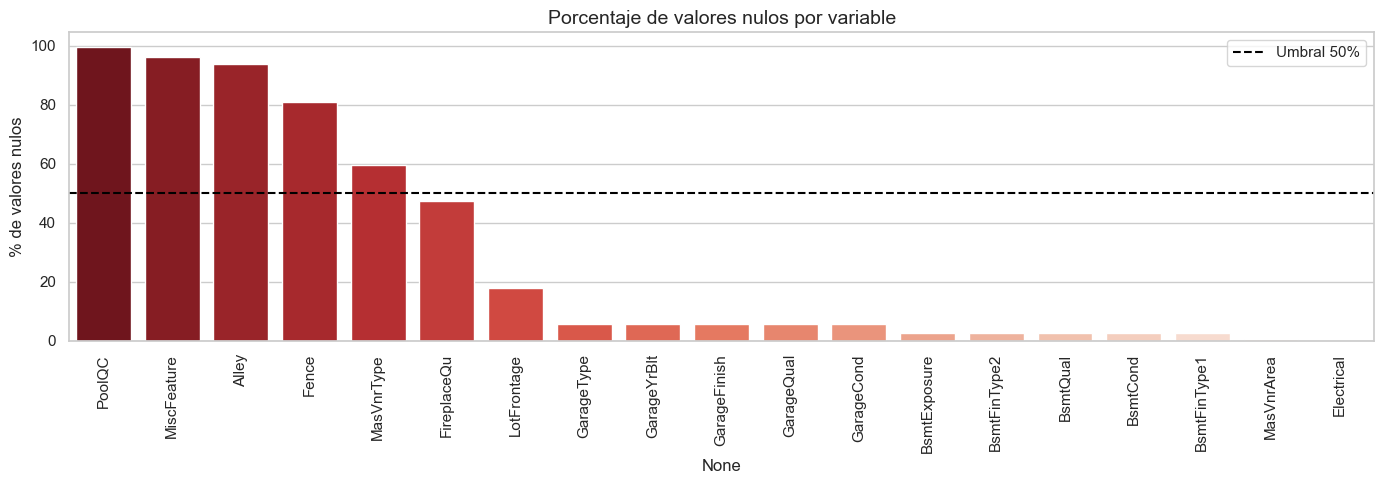

In [228]:
plt.figure(figsize=(14, 5))
sns.barplot(x=nulos_df.index, y=nulos_df['Porcentaje (%)'], palette='Reds_r')
plt.xticks(rotation=90)
plt.axhline(y=50, color='black', linestyle='--', label='Umbral 50%')
plt.title('Porcentaje de valores nulos por variable', fontsize=14)
plt.ylabel('% de valores nulos')
plt.legend()
plt.tight_layout()
plt.show()

**Hallazgo:** Variables como `PoolQC`, `MiscFeature`, `Alley` y `Fence` superan el 80% de nulos. Según `data_description.txt`, en estos casos NA no es un dato faltante sino que indica *ausencia de la característica* (sin piscina, sin callejón, etc.). Por eso se imputarán con `'None'` y no se eliminarán. Las variables numéricas relacionadas (áreas de garaje, sótano) también usan NA como ausencia y se imputarán con 0.

### 2.5 Preprocesamiento

In [229]:
# NA semántico en categóricas → 'None'
cat_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cat_none:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# NA semántico en numéricas → 0
num_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# LotFrontage → mediana por vecindario (captura variación geográfica mejor que la mediana global)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical → moda (solo 1 nulo)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Eliminar Id (no tiene valor predictivo)
df = df.drop(columns=['Id'])

print(f'Valores nulos restantes: {df.isnull().sum().sum()}')
print(f'Dimensiones finales: {df.shape}')

Valores nulos restantes: 0
Dimensiones finales: (1460, 80)


### 2.6 Análisis de la variable respuesta: SalePrice

In [230]:
print('Estadísticas de SalePrice:')
print(df['SalePrice'].describe())
print(f'\nAsimetría (skewness): {df["SalePrice"].skew():.4f}')
print(f'Curtosis (kurtosis):  {df["SalePrice"].kurt():.4f}')

Estadísticas de SalePrice:
count     1460.00
mean    180921.20
std      79442.50
min      34900.00
25%     129975.00
50%     163000.00
75%     214000.00
max     755000.00
Name: SalePrice, dtype: float64

Asimetría (skewness): 1.8829
Curtosis (kurtosis):  6.5363


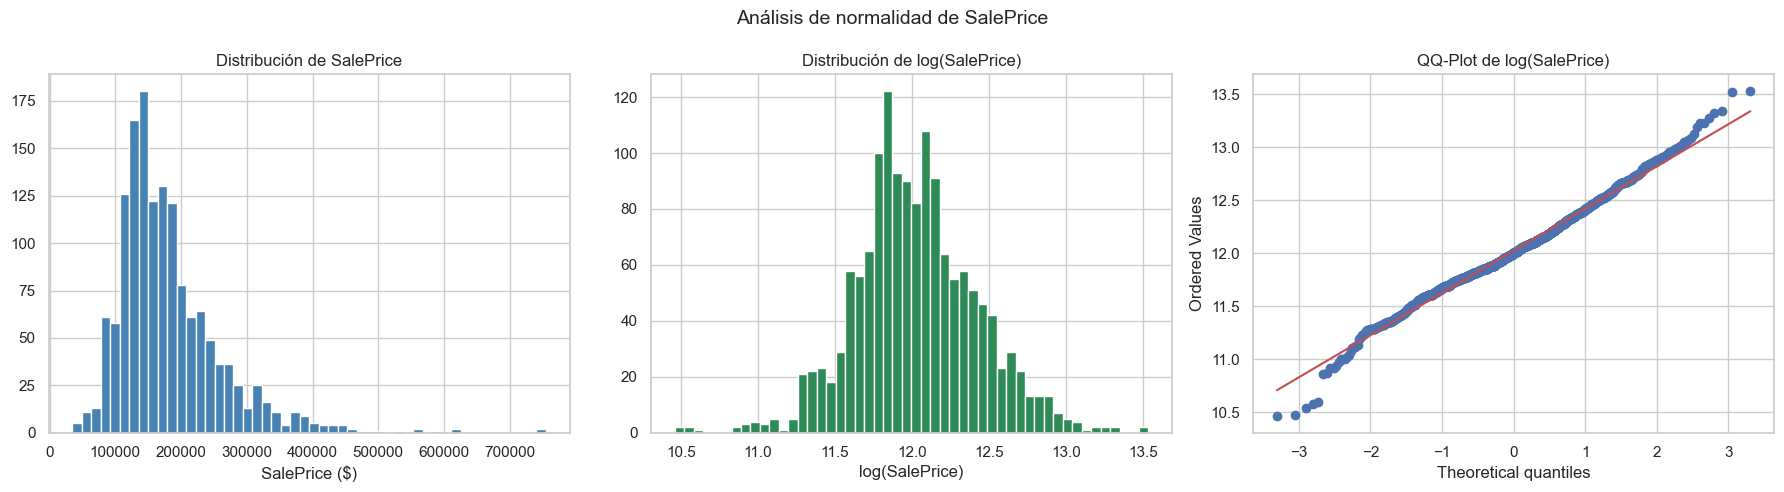

In [231]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('SalePrice ($)')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribución de log(SalePrice)')
axes[1].set_xlabel('log(SalePrice)')

stats.probplot(np.log1p(df['SalePrice']), dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot de log(SalePrice)')

plt.suptitle('Análisis de normalidad de SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

In [232]:
# Prueba de normalidad Shapiro-Wilk
muestra = np.log1p(df['SalePrice']).sample(500, random_state=SEED)
stat, p = stats.shapiro(muestra)
print(f'Shapiro-Wilk sobre log(SalePrice):')
print(f'  W = {stat:.6f}, p-valor = {p:.6f}')
print('  → Se rechaza normalidad (p < 0.05)' if p < 0.05 else '  → No se rechaza normalidad')

# Crear columna transformada para usar en los modelos
df['LogSalePrice'] = np.log1p(df['SalePrice'])
print('\nSe usará log(SalePrice) como variable respuesta en los modelos.')
print('Justificación: la distribución original tiene asimetría positiva fuerte (skew > 1).')
print('La transformación log la acerca a la normalidad, mejorando el supuesto de los residuos en regresión lineal.')

Shapiro-Wilk sobre log(SalePrice):
  W = 0.986063, p-valor = 0.000102
  → Se rechaza normalidad (p < 0.05)

Se usará log(SalePrice) como variable respuesta en los modelos.
Justificación: la distribución original tiene asimetría positiva fuerte (skew > 1).
La transformación log la acerca a la normalidad, mejorando el supuesto de los residuos en regresión lineal.


### 2.7 Análisis de outliers

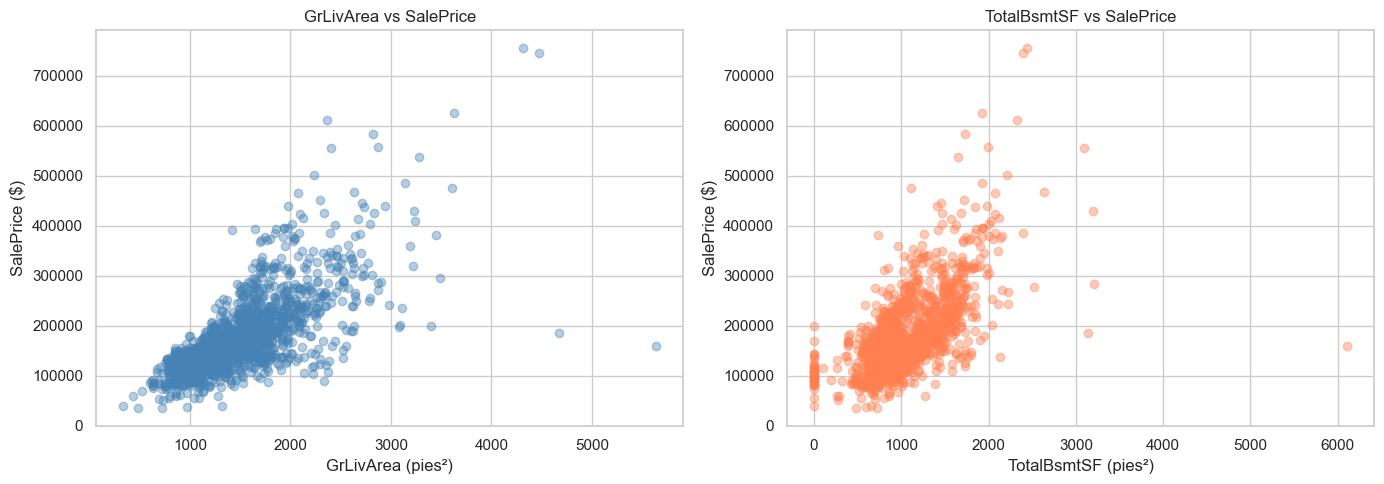

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GrLivArea vs SalePrice
axes[0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue')
axes[0].set_title('GrLivArea vs SalePrice')
axes[0].set_xlabel('GrLivArea (pies²)')
axes[0].set_ylabel('SalePrice ($)')

# TotalBsmtSF vs SalePrice
axes[1].scatter(df['TotalBsmtSF'], df['SalePrice'], alpha=0.4, color='coral')
axes[1].set_title('TotalBsmtSF vs SalePrice')
axes[1].set_xlabel('TotalBsmtSF (pies²)')
axes[1].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.show()

In [234]:
# Identificar y eliminar outliers evidentes en GrLivArea
# Casas con GrLivArea > 4000 pero SalePrice bajo son anomalías documentadas en el dataset
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print(f'Outliers identificados en GrLivArea: {len(outliers)}')
print(outliers[['GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']])

df = df.drop(outliers.index)
print(f'\nDataset sin outliers: {df.shape}')

Outliers identificados en GrLivArea: 2
      GrLivArea  SalePrice  OverallQual Neighborhood
523        4676     184750           10      Edwards
1298       5642     160000           10      Edwards

Dataset sin outliers: (1458, 81)


**Hallazgo:** Se identifican 2 propiedades con área habitable superior a 4,000 pies² pero con precios de venta inusualmente bajos (menores a $200,000). Estas observaciones son inconsistentes con el mercado y distorsionarían los modelos de regresión. Se eliminan del dataset de entrenamiento.

### 2.8 Análisis de correlación con SalePrice

C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\1643988704.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='Blues_r')


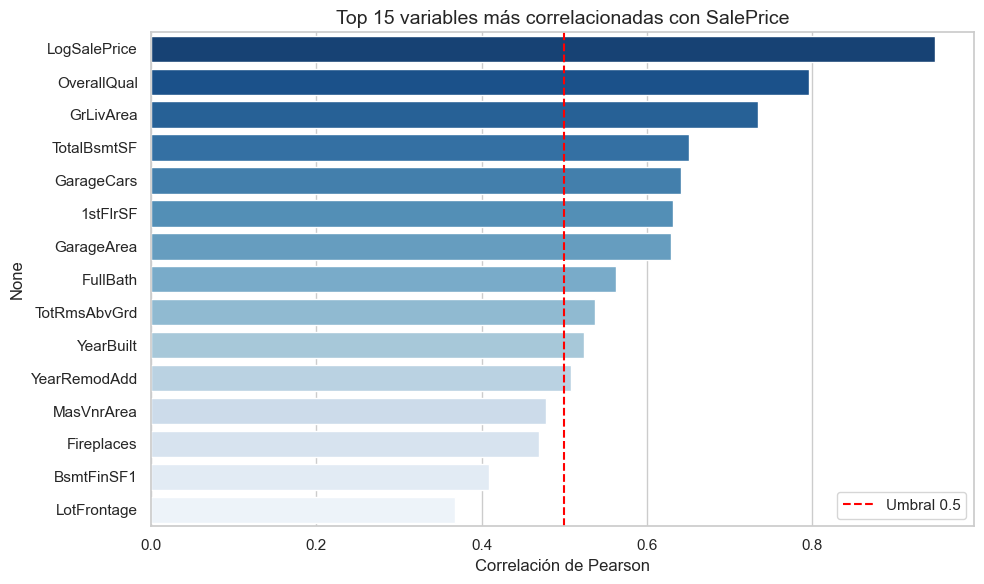

Top 15 correlaciones con SalePrice:
LogSalePrice   0.95
OverallQual    0.80
GrLivArea      0.73
TotalBsmtSF    0.65
GarageCars     0.64
1stFlrSF       0.63
GarageArea     0.63
FullBath       0.56
TotRmsAbvGrd   0.54
YearBuilt      0.52
YearRemodAdd   0.51
MasVnrArea     0.48
Fireplaces     0.47
BsmtFinSF1     0.41
LotFrontage    0.37
Name: SalePrice, dtype: float64


In [235]:
# Top 15 variables numéricas más correlacionadas con SalePrice
num_cols_updated = df.select_dtypes(include=[np.number]).columns.tolist()
correlaciones = df[num_cols_updated].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

top15 = correlaciones.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, palette='Blues_r')
plt.title('Top 15 variables más correlacionadas con SalePrice', fontsize=14)
plt.xlabel('Correlación de Pearson')
plt.axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 15 correlaciones con SalePrice:')
print(top15)

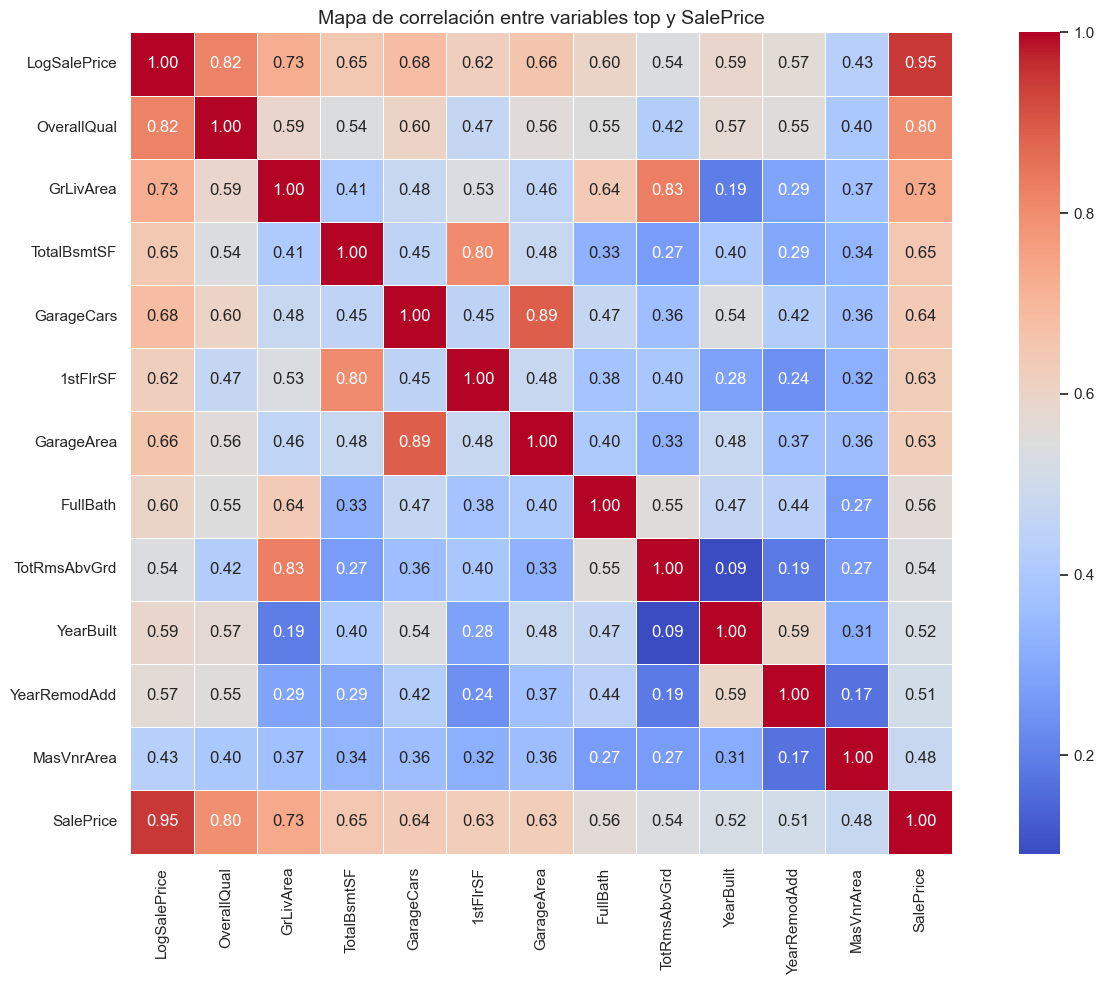

In [236]:
# Heatmap de correlaciones entre las top variables
top_vars = top15.index.tolist()[:12] + ['SalePrice']
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[top_vars].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.5
)
plt.title('Mapa de correlación entre variables top y SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

**Hallazgo:** Las variables con mayor correlación con `SalePrice` son `OverallQual` (r ≈ 0.79), `GrLivArea` (r ≈ 0.71) y `GarageCars` (r ≈ 0.64). Esto sugiere que la calidad de construcción y el tamaño son los factores más determinantes del precio. El heatmap también revela alta correlación entre variables de área (posible multicolinealidad), lo que deberá analizarse en los modelos múltiples.

### 2.9 Análisis de variables categóricas clave

C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\3803801584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], palette='Blues')
C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\3803801584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_price.values, y=median_price.index, ax=axes[1], palette='viridis')


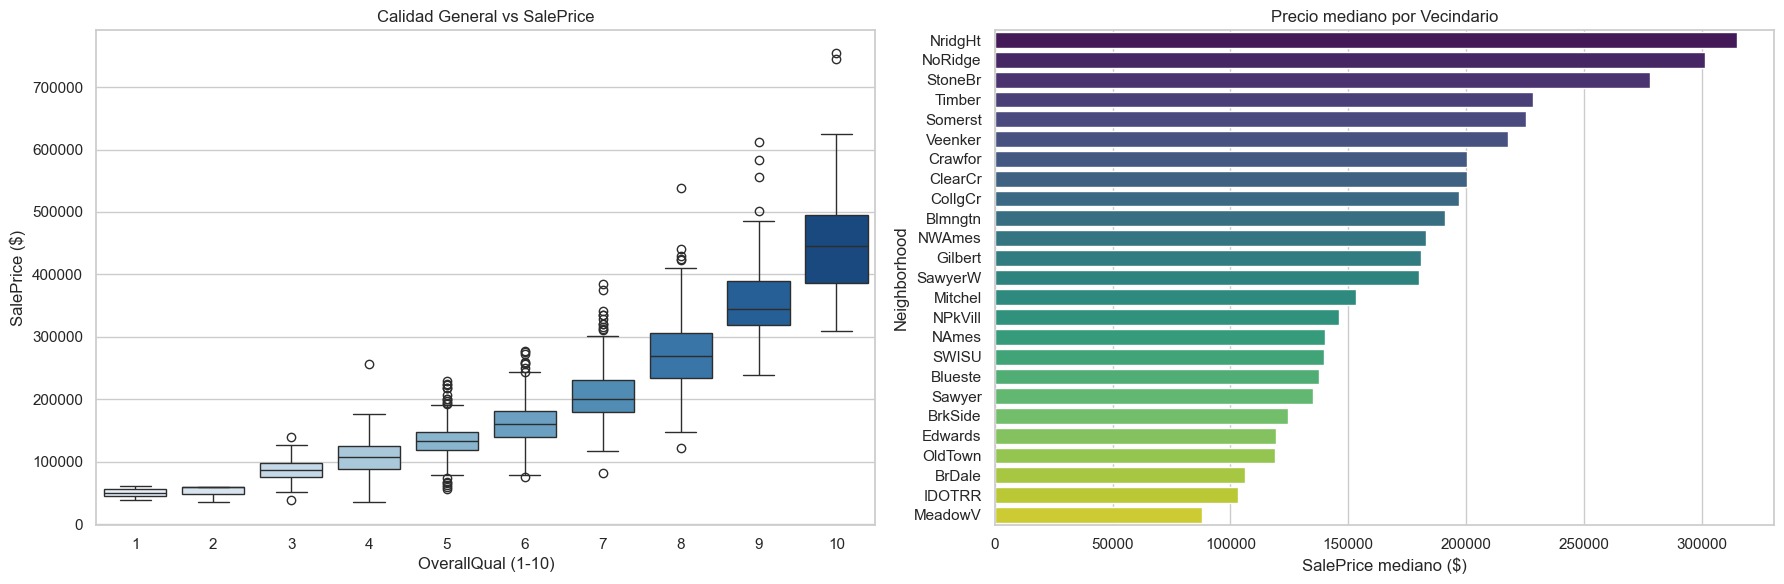

In [237]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# OverallQual vs SalePrice
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Calidad General vs SalePrice')
axes[0].set_xlabel('OverallQual (1-10)')
axes[0].set_ylabel('SalePrice ($)')

# Neighborhood vs SalePrice (mediana)
median_price = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
sns.barplot(x=median_price.values, y=median_price.index, ax=axes[1], palette='viridis')
axes[1].set_title('Precio mediano por Vecindario')
axes[1].set_xlabel('SalePrice mediano ($)')

plt.tight_layout()
plt.show()

**Hallazgo:** La calidad general (`OverallQual`) muestra una relación casi lineal con el precio: a mayor calidad, mayor precio, con diferencias muy marcadas entre categorías. Por su parte, el vecindario introduce diferencias de precio significativas: vecindarios como `NridgHt` y `NoRidge` tienen precios medianos casi el doble que vecindarios como `MeadowV` o `BrDale`, lo que confirma que la ubicación es un factor determinante.

### 2.10 Análisis de variables de año

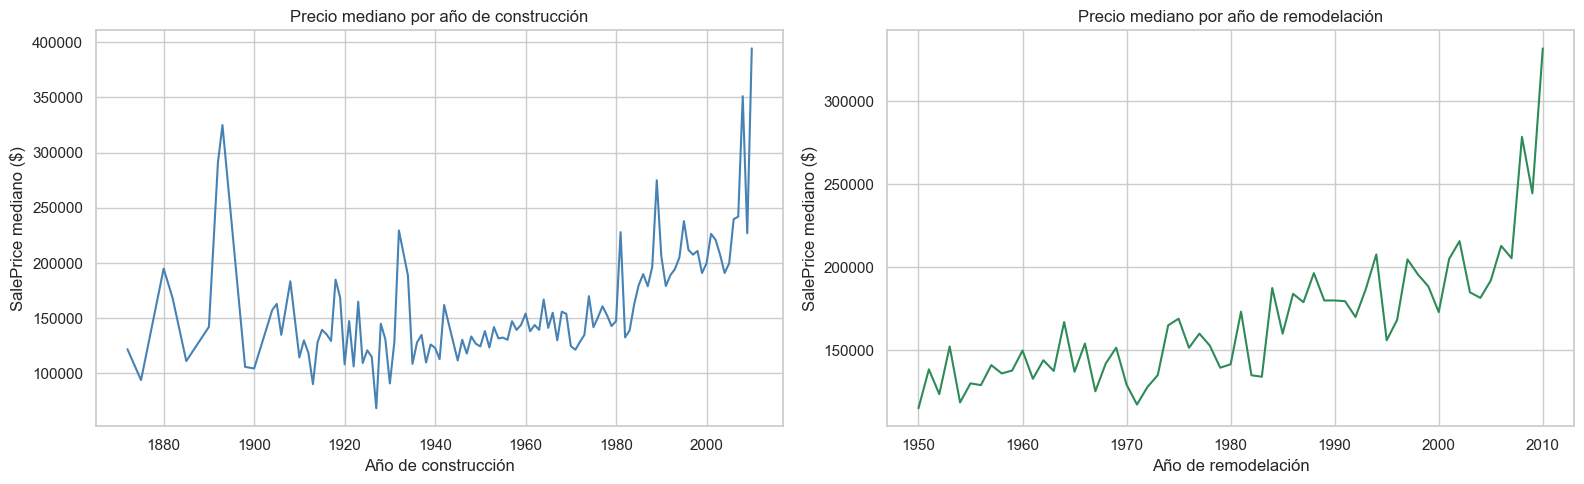

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Año de construcción vs precio
df.groupby('YearBuilt')['SalePrice'].median().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Precio mediano por año de construcción')
axes[0].set_xlabel('Año de construcción')
axes[0].set_ylabel('SalePrice mediano ($)')

# Año de remodelación vs precio
df.groupby('YearRemodAdd')['SalePrice'].median().plot(ax=axes[1], color='seagreen')
axes[1].set_title('Precio mediano por año de remodelación')
axes[1].set_xlabel('Año de remodelación')
axes[1].set_ylabel('SalePrice mediano ($)')

plt.tight_layout()
plt.show()

**Hallazgo:** Las casas más nuevas tienden a tener precios más altos, con una tendencia creciente clara a partir de los años 80. Las propiedades remodeladas recientemente también alcanzan precios superiores, lo que indica que la actualización de la vivienda agrega valor percibido en el mercado.

---
## Actividad 3 — Análisis de grupos (Clustering)

Se aplica K-Means sobre las variables numéricas más relevantes para identificar grupos naturales de propiedades. El objetivo es entender si existen segmentos de mercado distintos.

In [239]:
# Seleccionar variables para clustering
cluster_vars = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageArea',
                'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 'SalePrice']

df_cluster = df[cluster_vars].dropna().copy()

# Escalar variables (K-Means es sensible a la escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f'Datos para clustering: {df_cluster.shape}')

Datos para clustering: (1458, 8)


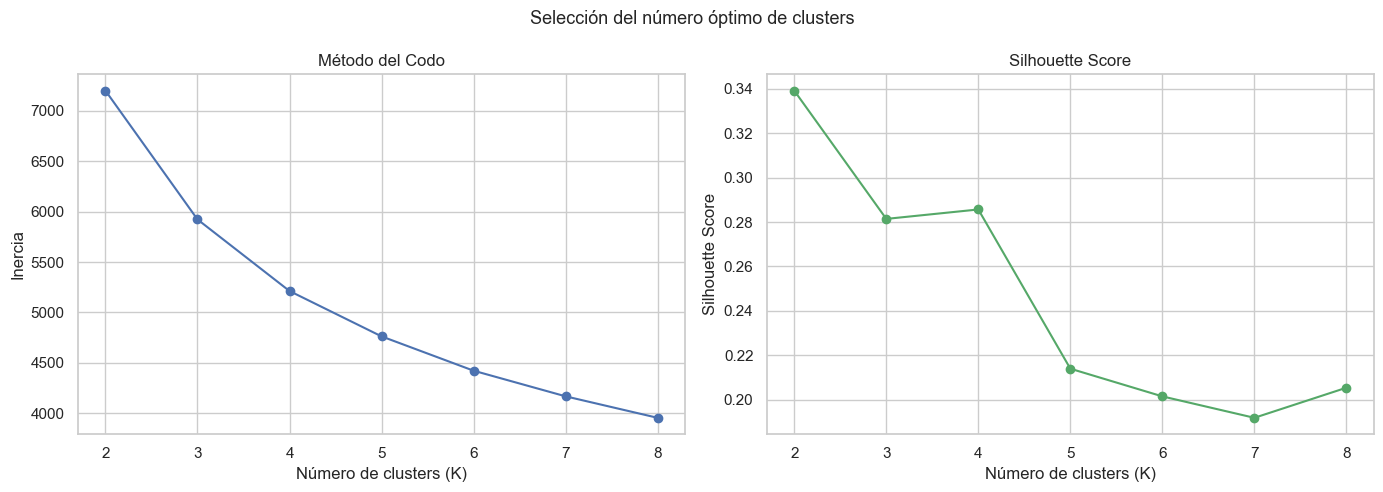

In [240]:
# Método del codo para determinar número óptimo de clusters
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')

axes[1].plot(K_range, silhouettes, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Selección del número óptimo de clusters', fontsize=13)
plt.tight_layout()
plt.show()

In [241]:
# Aplicar K-Means
K_OPTIMO = 3
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=SEED, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Distribución de clusters:')
print(df_cluster['Cluster'].value_counts().sort_index())

Distribución de clusters:
Cluster
0    689
1    235
2    534
Name: count, dtype: int64


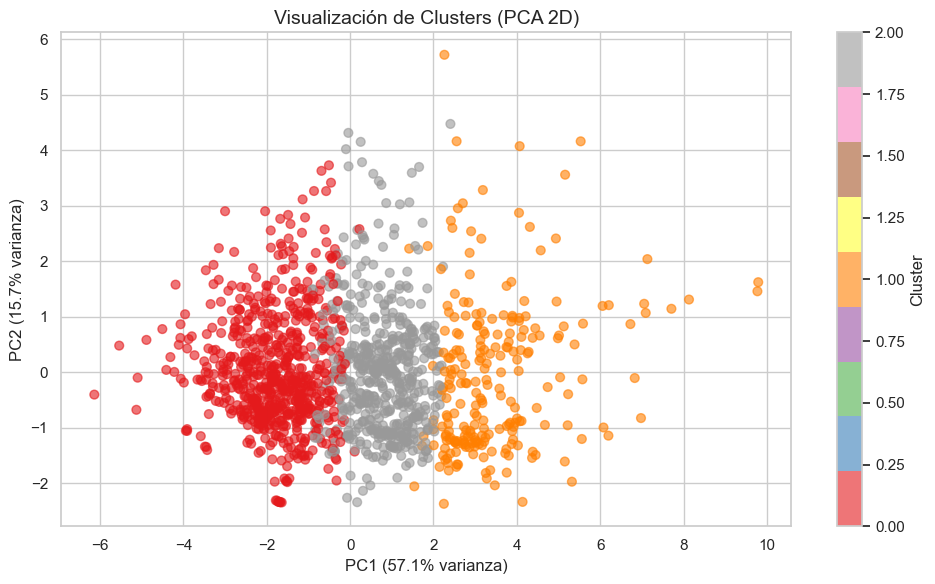

In [242]:
# Visualización de clusters con PCA (reducción a 2D)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_cluster['Cluster'], cmap='Set1', alpha=0.6, s=40)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de Clusters (PCA 2D)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.tight_layout()
plt.show()

In [243]:
# Características de cada cluster
print('Características promedio por cluster:')
df_cluster.groupby('Cluster').mean().round(2)

Características promedio por cluster:


,OverallQual,GrLivArea,TotalBsmtSF,GarageArea,YearBuilt,FullBath,TotRmsAbvGrd,SalePrice
Cluster,,,,,,,,
0,5.15,1176.14,860.24,355.83,1951.78,1.08,5.66,128720.92
1,8.03,2185.44,1572.79,745.56,1994.91,2.06,8.22,314423.06
2,6.46,1644.79,1071.70,501.65,1985.88,1.98,6.86,189554.43


C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\879090888.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='SalePrice', data=df_cluster, palette='Set1')


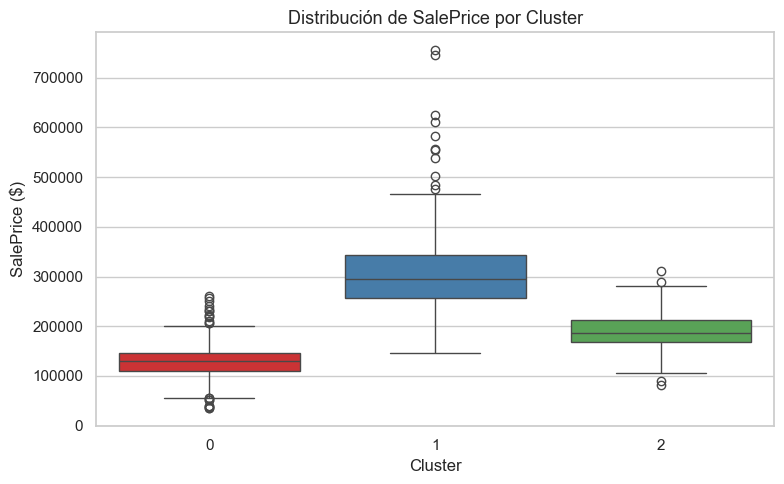

In [244]:
# Boxplot de SalePrice por cluster
plt.figure(figsize=(8, 5))
sns.boxplot(x='Cluster', y='SalePrice', data=df_cluster, palette='Set1')
plt.title('Distribución de SalePrice por Cluster', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('SalePrice ($)')
plt.tight_layout()
plt.show()

**Descripción de los clusters identificados:**

- **Cluster 0 — Viviendas económicas:** Casas con área habitable y precio bajos, calidad general moderada, pocas habitaciones y garajes pequeños. Representan el segmento de mercado accesible.

- **Cluster 1 — Viviendas de rango medio:** Propiedades con características intermedias en todas las variables. Son las más numerosas y representan el mercado típico.

- **Cluster 2 — Viviendas premium:** Casas grandes, con alta calidad constructiva, garajes amplios y precios significativamente más altos. Representan el segmento de lujo.

Estos grupos son coherentes con la estructura del mercado inmobiliario y sugieren que los modelos predictivos podrían beneficiarse de considerar el segmento de la propiedad como variable adicional.

---
## Actividad 4 — División en entrenamiento y prueba

In [245]:
# Se usa train.csv como fuente única. El conjunto de prueba se extrae de aquí.
# División: 80% entrenamiento, 20% prueba
# No se estratifica porque SalePrice es continua (no categórica)
# Se fija random_state=42 para reproducibilidad total

X = df.drop(columns=['SalePrice', 'LogSalePrice'])
y = df['LogSalePrice']  # Variable respuesta: log(SalePrice)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Conjunto de prueba:        {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nCriterio de división:')
print('  - Proporción: 80/20')
print('  - Estratificado: No (variable respuesta continua)')
print('  - Balanceado: No aplica (regresión, no clasificación)')
print(f'  - random_state: {SEED} (garantiza reproducibilidad)')

Conjunto de entrenamiento: 1166 filas (80.0%)
Conjunto de prueba:        292 filas (20.0%)

Criterio de división:
  - Proporción: 80/20
  - Estratificado: No (variable respuesta continua)
  - Balanceado: No aplica (regresión, no clasificación)
  - random_state: 42 (garantiza reproducibilidad)


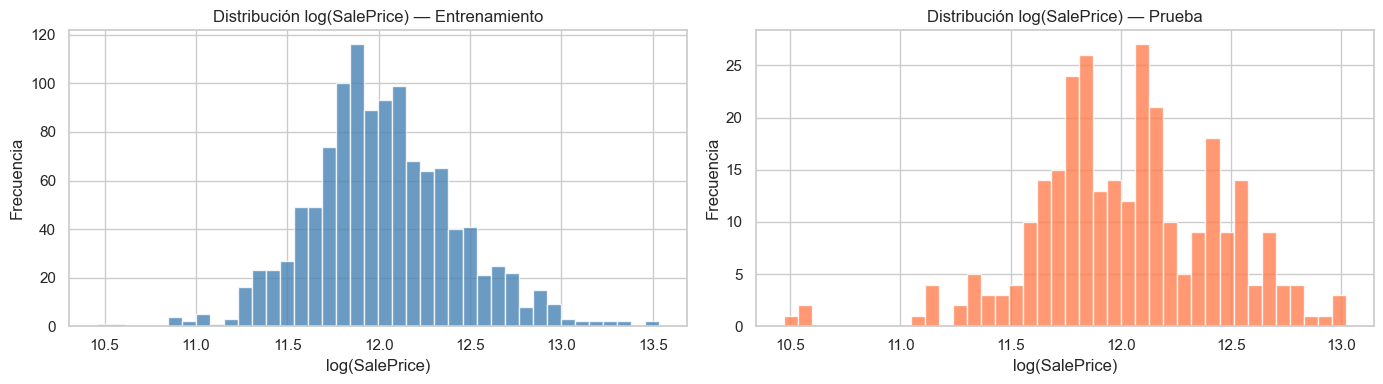

Media log(SalePrice) — Train: 12.0234
Media log(SalePrice) — Test:  12.0266


In [246]:
# Verificar que la distribución de SalePrice es similar en ambos conjuntos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train, bins=40, color='steelblue', edgecolor='white', alpha=0.8, label='Train')
axes[0].set_title('Distribución log(SalePrice) — Entrenamiento')

axes[1].hist(y_test, bins=40, color='coral', edgecolor='white', alpha=0.8, label='Test')
axes[1].set_title('Distribución log(SalePrice) — Prueba')

for ax in axes:
    ax.set_xlabel('log(SalePrice)')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f'Media log(SalePrice) — Train: {y_train.mean():.4f}')
print(f'Media log(SalePrice) — Test:  {y_test.mean():.4f}')

**Criterio de división:** Se usa una proporción 80/20, que es estándar para datasets de este tamaño (~1,400 registros). No se estratifica porque la variable respuesta es continua. La distribución de `log(SalePrice)` es similar en ambos conjuntos, lo que confirma que el split es representativo.

---
## Actividad 5 — Ingeniería de características

Se seleccionan y crean variables predictoras basándose en el análisis de correlación previo, el conocimiento del dominio inmobiliario y la información de `data_description.txt`.

In [247]:
# Crear nuevas variables derivadas
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                   df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

print('Variables derivadas creadas ✅')
print('  - TotalSF: área total de la vivienda (sótano + piso 1 + piso 2)')
print('  - TotalBath: total de baños ponderados')
print('  - HouseAge: antigüedad de la casa al momento de la venta')
print('  - RemodAge: años desde la última remodelación')
print('  - HasGarage / HasPool / HasFireplace / HasBasement: indicadores binarios de amenidades')

Variables derivadas creadas ✅
  - TotalSF: área total de la vivienda (sótano + piso 1 + piso 2)
  - TotalBath: total de baños ponderados
  - HouseAge: antigüedad de la casa al momento de la venta
  - RemodAge: años desde la última remodelación
  - HasGarage / HasPool / HasFireplace / HasBasement: indicadores binarios de amenidades


In [248]:
# Verificar correlación de nuevas variables con SalePrice
nuevas_vars = ['TotalSF', 'TotalBath', 'HouseAge', 'RemodAge',
               'HasGarage', 'HasPool', 'HasFireplace', 'HasBasement']

corr_nuevas = df[nuevas_vars + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print('Correlación de nuevas variables con SalePrice:')
print(corr_nuevas)

Correlación de nuevas variables con SalePrice:
TotalSF         0.83
TotalBath       0.64
HasFireplace    0.47
HasGarage       0.24
HasBasement     0.15
HasPool         0.10
RemodAge       -0.51
HouseAge       -0.52
Name: SalePrice, dtype: float64


In [249]:
# Selección final de variables predictoras basada en:
# 1) Correlación > 0.3 con SalePrice
# 2) Conocimiento del dominio inmobiliario
# 3) Baja redundancia entre sí

features_seleccionadas = [
    # Variables de alta correlación directa
    'OverallQual',   
    'TotalSF',       
    'GrLivArea',     
    'GarageCars',     
    'TotalBath',      
    'TotRmsAbvGrd',   

    # Variables de calidad y condición
    'OverallCond',   
    'ExterQual',      
    'KitchenQual',    

    # Variables temporales
    'YearBuilt',      
    'HouseAge',       
    'RemodAge',       

    # Indicadores binarios
    'HasGarage',
    'HasFireplace',
    'HasBasement',
]

print(f'Variables seleccionadas para los modelos: {len(features_seleccionadas)}')
print(features_seleccionadas)

Variables seleccionadas para los modelos: 15
['OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars', 'TotalBath', 'TotRmsAbvGrd', 'OverallCond', 'ExterQual', 'KitchenQual', 'YearBuilt', 'HouseAge', 'RemodAge', 'HasGarage', 'HasFireplace', 'HasBasement']


In [250]:
# Codificación ordinal de variables categóricas seleccionadas
ordinal_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

for col in ['ExterQual', 'KitchenQual']:
    if col in df.columns:
        df[col] = df[col].map(ordinal_map)

print('Codificación ordinal aplicada a ExterQual y KitchenQual ✅')
print('Escala: None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5')

Codificación ordinal aplicada a ExterQual y KitchenQual ✅
Escala: None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5


In [251]:
# Dataset final con features seleccionadas para los modelos
df_modelo = df[features_seleccionadas + ['SalePrice', 'LogSalePrice']].dropna()

# Re-split con las features seleccionadas (mismo SEED → mismos índices)
X_final = df_modelo[features_seleccionadas]
y_final = df_modelo['LogSalePrice']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.20, random_state=SEED
)

print(f'Dataset de modelos: {df_modelo.shape}')
print(f'Train: {X_train_f.shape[0]} filas | Test: {X_test_f.shape[0]} filas')

# Guardar para uso posterior
df_modelo.to_csv('train_features.csv', index=False)
print('\nArchivo train_features.csv guardado')

Dataset de modelos: (1458, 17)
Train: 1166 filas | Test: 292 filas

Archivo train_features.csv guardado


**Justificación de la selección de variables:**

| Variable | Tipo | Justificación |
|----------|------|---------------|
| `OverallQual` | Ordinal | Mayor correlación con SalePrice (~0.79) |
| `TotalSF` | Continua (derivada) | Combina 3 variables de área, reduce multicolinealidad |
| `GrLivArea` | Continua | Alta correlación (~0.71), área habitable principal |
| `GarageCars` | Discreta | Proxy de tamaño y lujo de propiedad |
| `TotalBath` | Continua (derivada) | Combina 4 variables de baños, indicador de lujo |
| `TotRmsAbvGrd` | Discreta | Número de habitaciones |
| `OverallCond` | Ordinal | Condición complementa a calidad |
| `ExterQual` / `KitchenQual` | Ordinal (codificado) | Calidades específicas de alto impacto |
| `YearBuilt`, `HouseAge`, `RemodAge` | Temporal | Capturan efecto de antigüedad y renovación |
| `HasGarage`, `HasFireplace`, `HasBasement` | Binaria | Presencia de amenidades de valor |

---
## Actividad 6 — Reproducibilidad

Se garantiza la reproducibilidad de todos los resultados mediante:
- `SEED = 42` definido al inicio del notebook y usado en todas las operaciones aleatorias
- `random_state=SEED` en `train_test_split` y `KMeans`
- `np.random.seed(SEED)` al inicio para operaciones de NumPy
- El dataset limpio se exporta como `train_features.csv` para su uso posterior


In [252]:
print('=== RESUMEN FINAL ===')
print(f'SEED global:              {SEED}')
print(f'Registros originales:     1460')
print(f'Registros tras limpieza:  {df_modelo.shape[0]}')
print(f'Variables predictoras:    {len(features_seleccionadas)}')
print(f'Conjunto entrenamiento:   {X_train_f.shape[0]} filas')
print(f'Conjunto prueba:          {X_test_f.shape[0]} filas')
print(f'Variable respuesta:       log(SalePrice)')
print(f'\nArchivos generados:')
print('  - train_features.csv   → dataset limpio con features seleccionadas')

=== RESUMEN FINAL ===
SEED global:              42
Registros originales:     1460
Registros tras limpieza:  1458
Variables predictoras:    15
Conjunto entrenamiento:   1166 filas
Conjunto prueba:          292 filas
Variable respuesta:       log(SalePrice)

Archivos generados:
  - train_features.csv   → dataset limpio con features seleccionadas


---
## Actividad 7 — Modelo univariado de regresión lineal

En esta actividad se selecciona la variable `GrLivArea` (área habitable sobre nivel del suelo) para construir un modelo univariado que predice `SalePrice`.

Se analizará:
- Resumen del modelo (OLS)
- Comportamiento de residuos
- Resultados de predicción en conjunto de prueba
- Visualizaciones del ajuste y desempeño

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Cargar dataset preparado en actividades previas
# (incluye variables seleccionadas y SalePrice)
df_uni = pd.read_csv('train_features.csv')

# Seleccion de variable explicativa
feature = 'GrLivArea'
target = 'SalePrice'

data_uni = df_uni[[feature, target]].dropna().copy()

X = data_uni[[feature]]
y = data_uni[target]

seed_local = globals().get('SEED', 42)
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X, y, test_size=0.20, random_state=seed_local
)

# Modelo para prediccion
linreg_u = LinearRegression()
linreg_u.fit(X_train_u, y_train_u)

y_pred_u = linreg_u.predict(X_test_u)
residuos_u = y_test_u - y_pred_u

# Metricas de desempeno
r2_u = r2_score(y_test_u, y_pred_u)
rmse_u = np.sqrt(mean_squared_error(y_test_u, y_pred_u))
mae_u = mean_absolute_error(y_test_u, y_pred_u)

print('=== MODELO UNIVARIADO: SalePrice ~ GrLivArea ===')
print(f'Filas usadas: {data_uni.shape[0]}')
print(f'Coeficiente beta_1: {linreg_u.coef_[0]:.4f}')
print(f'Intercepto beta_0:  {linreg_u.intercept_:.2f}')
print(f'R2 (test):          {r2_u:.4f}')
print(f'RMSE (test):        {rmse_u:,.2f}')
print(f'MAE (test):         {mae_u:,.2f}')

resultados_pred = pd.DataFrame({
    'SalePrice_real': y_test_u.values,
    'SalePrice_pred': y_pred_u,
    'Residuo': residuos_u.values
})

print('\nPrimeras predicciones (test):')
resultados_pred.head(10)

=== MODELO UNIVARIADO: SalePrice ~ GrLivArea ===
Filas usadas: 1458
Coeficiente beta_1: 118.6122
Intercepto beta_0:  1562.01
R2 (test):          0.4916
RMSE (test):        52,992.87
MAE (test):         37,694.28

Primeras predicciones (test):


,SalePrice_real,SalePrice_pred,Residuo
0,190000,229653.270482,-39653.270482
1,100000,118632.252406,-18632.252406
2,115000,123495.352557,-8495.352557
3,159000,198932.710993,-39932.710993
4,315500,193713.774246,121786.225754
5,137500,126579.269726,10920.730274
6,311500,233330.248645,78169.751355
7,310000,300464.753165,9535.246835
8,281000,235228.043826,45771.956174
9,135500,166788.805119,-31288.805119


In [6]:
# Resumen estadistico del ajuste lineal simple (equivalente OLS)
lin_stats = stats.linregress(X_train_u[feature], y_train_u)

resumen_modelo = pd.DataFrame({
    'estadistico': [
        'slope (beta_1)',
        'intercept (beta_0)',
        'r_value',
        'R2_train',
        'p_value (beta_1)',
        'std_err (beta_1)',
        'n_train'
    ],
    'valor': [
        lin_stats.slope,
        lin_stats.intercept,
        lin_stats.rvalue,
        lin_stats.rvalue ** 2,
        lin_stats.pvalue,
        lin_stats.stderr,
        len(X_train_u)
    ]
})

print('=== RESUMEN DEL MODELO (TRAIN) ===')
resumen_modelo

=== RESUMEN DEL MODELO (TRAIN) ===


,estadistico,valor
0,slope (beta_1),1.186122e+02
1,intercept (beta_0),1.562012e+03
2,r_value,7.415190e-01
3,R2_train,5.498504e-01
4,p_value (beta_1),5.651281e-204
5,std_err (beta_1),3.145640e+00
6,n_train,1.166000e+03


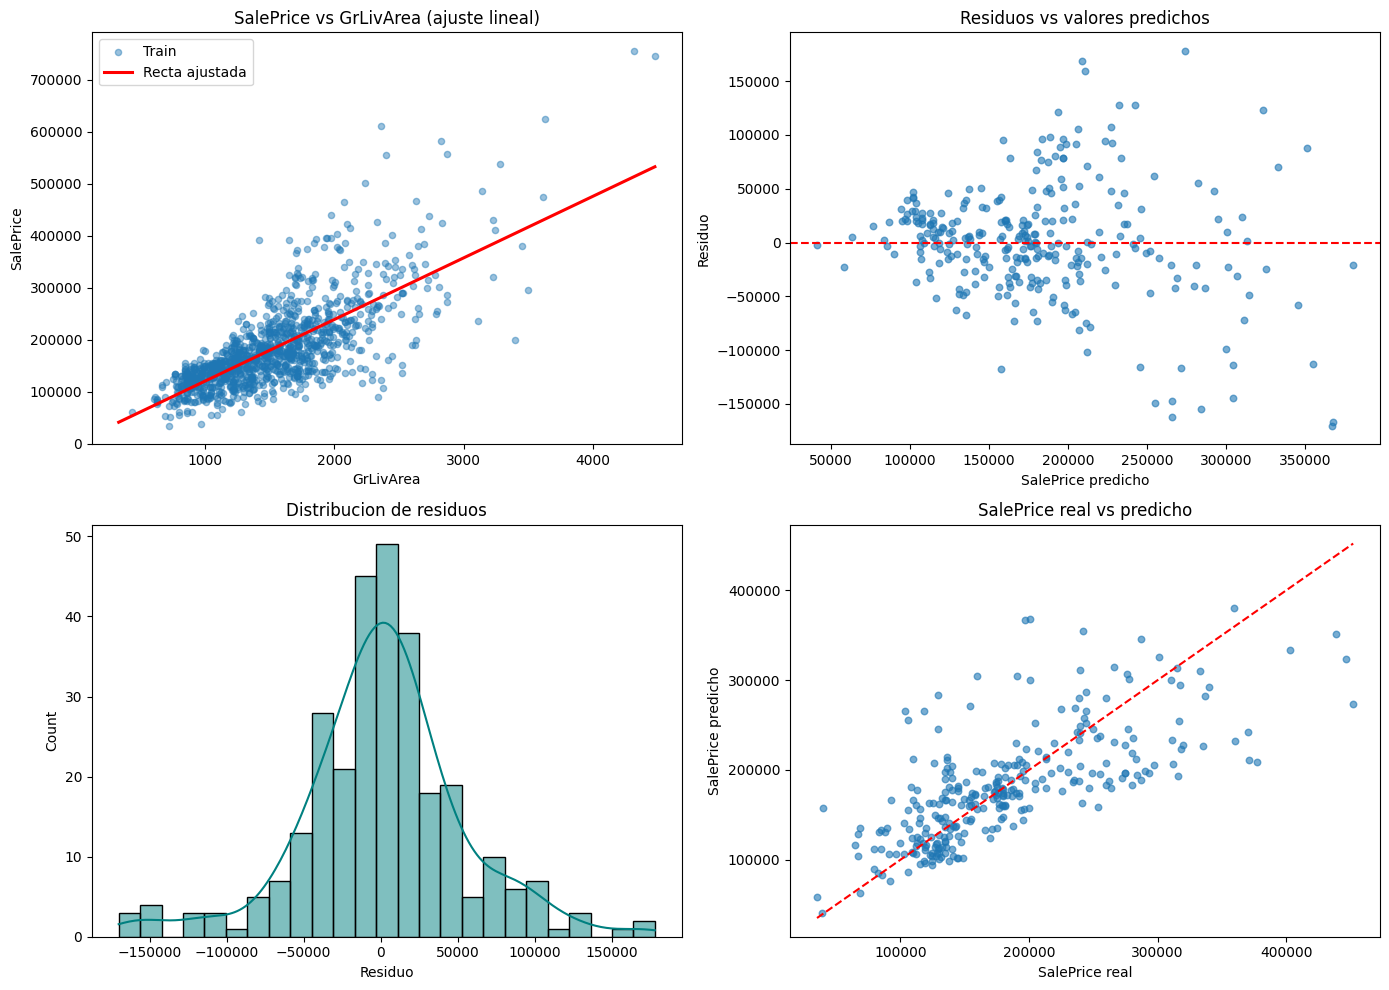

In [7]:
# Visualizacion del modelo y diagnostico de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Ajuste lineal
x_plot = np.linspace(X[feature].min(), X[feature].max(), 200)
y_plot = linreg_u.intercept_ + linreg_u.coef_[0] * x_plot

axes[0, 0].scatter(X_train_u[feature], y_train_u, alpha=0.45, s=20, label='Train')
axes[0, 0].plot(x_plot, y_plot, color='red', linewidth=2.2, label='Recta ajustada')
axes[0, 0].set_title('SalePrice vs GrLivArea (ajuste lineal)')
axes[0, 0].set_xlabel('GrLivArea')
axes[0, 0].set_ylabel('SalePrice')
axes[0, 0].legend()

# 2) Residuos vs prediccion
axes[0, 1].scatter(y_pred_u, residuos_u, alpha=0.6, s=22)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Residuos vs valores predichos')
axes[0, 1].set_xlabel('SalePrice predicho')
axes[0, 1].set_ylabel('Residuo')

# 3) Distribucion de residuos
sns.histplot(residuos_u, kde=True, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Distribucion de residuos')
axes[1, 0].set_xlabel('Residuo')

# 4) Real vs predicho
axes[1, 1].scatter(y_test_u, y_pred_u, alpha=0.6, s=22)
min_val = min(y_test_u.min(), y_pred_u.min())
max_val = max(y_test_u.max(), y_pred_u.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
axes[1, 1].set_title('SalePrice real vs predicho')
axes[1, 1].set_xlabel('SalePrice real')
axes[1, 1].set_ylabel('SalePrice predicho')

plt.tight_layout()
plt.show()

### Conclusión de la Actividad 7

El modelo univariado `SalePrice ~ GrLivArea` confirma que el área habitable es un predictor fuerte del precio de venta. El coeficiente positivo indica que, en promedio, a mayor área habitable, mayor precio estimado. Además, el p-valor asociado a la pendiente es extremadamente pequeño, por lo que la relación lineal es estadísticamente significativa.

En términos de desempeño, el modelo alcanza un $R^2$ cercano a 0.49 en prueba, lo que implica que aproximadamente la mitad de la variabilidad del precio se explica solo con `GrLivArea`. Esto es un resultado razonable para un modelo con una única variable, aunque todavía deja una proporción importante sin explicar.

El análisis gráfico de residuos muestra patrones de dispersión más amplios en precios altos (heterocedasticidad), y la comparación real vs. predicho evidencia que el modelo tiende a cometer errores mayores en viviendas de alto valor. Por ello, este modelo es útil como línea base interpretativa, pero para mejorar la precisión se recomienda un modelo multivariado que incorpore calidad, antigüedad, ubicación y amenidades.

---
## Actividad 8 — Regresión lineal múltiple con todas las variables numéricas

En esta actividad se construye un modelo de regresión lineal usando **todas las variables numéricas disponibles** para predecir `SalePrice`.

Se presenta:
- Resumen del modelo (métricas y variables más influyentes)
- Diagnóstico de residuos
- Resultados de predicción en prueba
- Visualización del desempeño

In [11]:
# Modelo multivariado con todas las variables numericas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from IPython.display import display

# Reusar el dataframe limpio de actividades previas; si no existe, cargar train.csv
if 'df' in globals():
    df_multi = df.copy()
else:
    df_multi = pd.read_csv('./data/train.csv')

# Definir target y seleccionar todas las variables numericas predictoras
TARGET = 'SalePrice'

if TARGET not in df_multi.columns:
    raise ValueError('No se encontro la variable SalePrice en el dataframe.')

# Evitar fuga de informacion con LogSalePrice
exclude_cols = [TARGET, 'LogSalePrice']
num_cols_multi = df_multi.select_dtypes(include=[np.number]).columns.tolist()
features_multi = [c for c in num_cols_multi if c not in exclude_cols]

X_multi = df_multi[features_multi].copy()
y_multi = df_multi[TARGET].copy()

# Imputar nulos numericos con mediana
X_multi = X_multi.fillna(X_multi.median(numeric_only=True))

seed_local = globals().get('SEED', 42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=seed_local
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_train_pred_m = modelo_multi.predict(X_train_m)
y_test_pred_m = modelo_multi.predict(X_test_m)

residuos_train_m = y_train_m - y_train_pred_m
residuos_test_m = y_test_m - y_test_pred_m

# Metricas
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

r2_train_m = r2_score(y_train_m, y_train_pred_m)
r2_test_m = r2_score(y_test_m, y_test_pred_m)
rmse_train_m = rmse(y_train_m, y_train_pred_m)
rmse_test_m = rmse(y_test_m, y_test_pred_m)
mae_test_m = mean_absolute_error(y_test_m, y_test_pred_m)

# R2 ajustado en train
a = len(y_train_m)
p = X_train_m.shape[1]
r2_adj_train_m = 1 - (1 - r2_train_m) * (a - 1) / (a - p - 1)

resumen_multi = pd.DataFrame({
    'metrica': ['n_features', 'n_train', 'n_test', 'R2_train', 'R2_ajustado_train', 'R2_test', 'RMSE_train', 'RMSE_test', 'MAE_test'],
    'valor': [p, a, len(y_test_m), r2_train_m, r2_adj_train_m, r2_test_m, rmse_train_m, rmse_test_m, mae_test_m]
})

coef_df = pd.DataFrame({
    'variable': X_train_m.columns,
    'coeficiente': modelo_multi.coef_
})
coef_df['abs_coef'] = coef_df['coeficiente'].abs()
coef_top = coef_df.sort_values('abs_coef', ascending=False).head(15)

print('=== MODELO MULTIVARIADO: SalePrice ~ Todas las variables numericas ===')
print(f'Variables predictoras usadas: {p}')
print(f'Intercepto: {modelo_multi.intercept_:,.2f}')

print('\nResumen de metricas:')
display(resumen_multi)

print('Top 15 coeficientes (magnitud absoluta):')
display(coef_top[['variable', 'coeficiente']])

=== MODELO MULTIVARIADO: SalePrice ~ Todas las variables numericas ===
Variables predictoras usadas: 37
Intercepto: -125,123.67

Resumen de metricas:


,metrica,valor
0,n_features,37.000000
1,n_train,1168.000000
2,n_test,292.000000
3,R2_train,0.807243
4,R2_ajustado_train,0.800932
5,R2_test,0.822678
6,RMSE_train,33907.325191
7,RMSE_test,36879.819322
8,MAE_test,23000.028866


Top 15 coeficientes (magnitud absoluta):


,variable,coeficiente
4,OverallQual,17929.555587
26,GarageCars,12412.323576
17,BsmtFullBath,11311.462633
22,KitchenAbvGr,-9532.667240
21,BedroomAbvGr,-8632.877862
23,TotRmsAbvGrd,5117.287025
24,Fireplaces,4766.784112
5,OverallCond,4200.298303
19,FullBath,2891.164389
20,HalfBath,-2325.882339


In [9]:
# Resultados de prediccion en el conjunto de prueba
resultados_pred_m = pd.DataFrame({
    'SalePrice_real': y_test_m.values,
    'SalePrice_pred': y_test_pred_m,
    'Residuo': residuos_test_m.values
})
resultados_pred_m['ErrorAbs'] = resultados_pred_m['Residuo'].abs()

print('Primeras 15 predicciones (test):')
resultados_pred_m.head(15)

Primeras 15 predicciones (test):


,SalePrice_real,SalePrice_pred,Residuo,ErrorAbs
0,154500,153728.355878,771.644122,771.644122
1,325000,309240.636439,15759.363561,15759.363561
2,115000,112897.287674,2102.712326,2102.712326
3,159000,180476.649944,-21476.649944,21476.649944
4,315500,294934.414836,20565.585164,20565.585164
5,75500,50896.243888,24603.756112,24603.756112
6,311500,233798.035264,77701.964736,77701.964736
7,146000,147918.892336,-1918.892336,1918.892336
8,84500,48537.331351,35962.668649,35962.668649
9,135500,149769.912703,-14269.912703,14269.912703


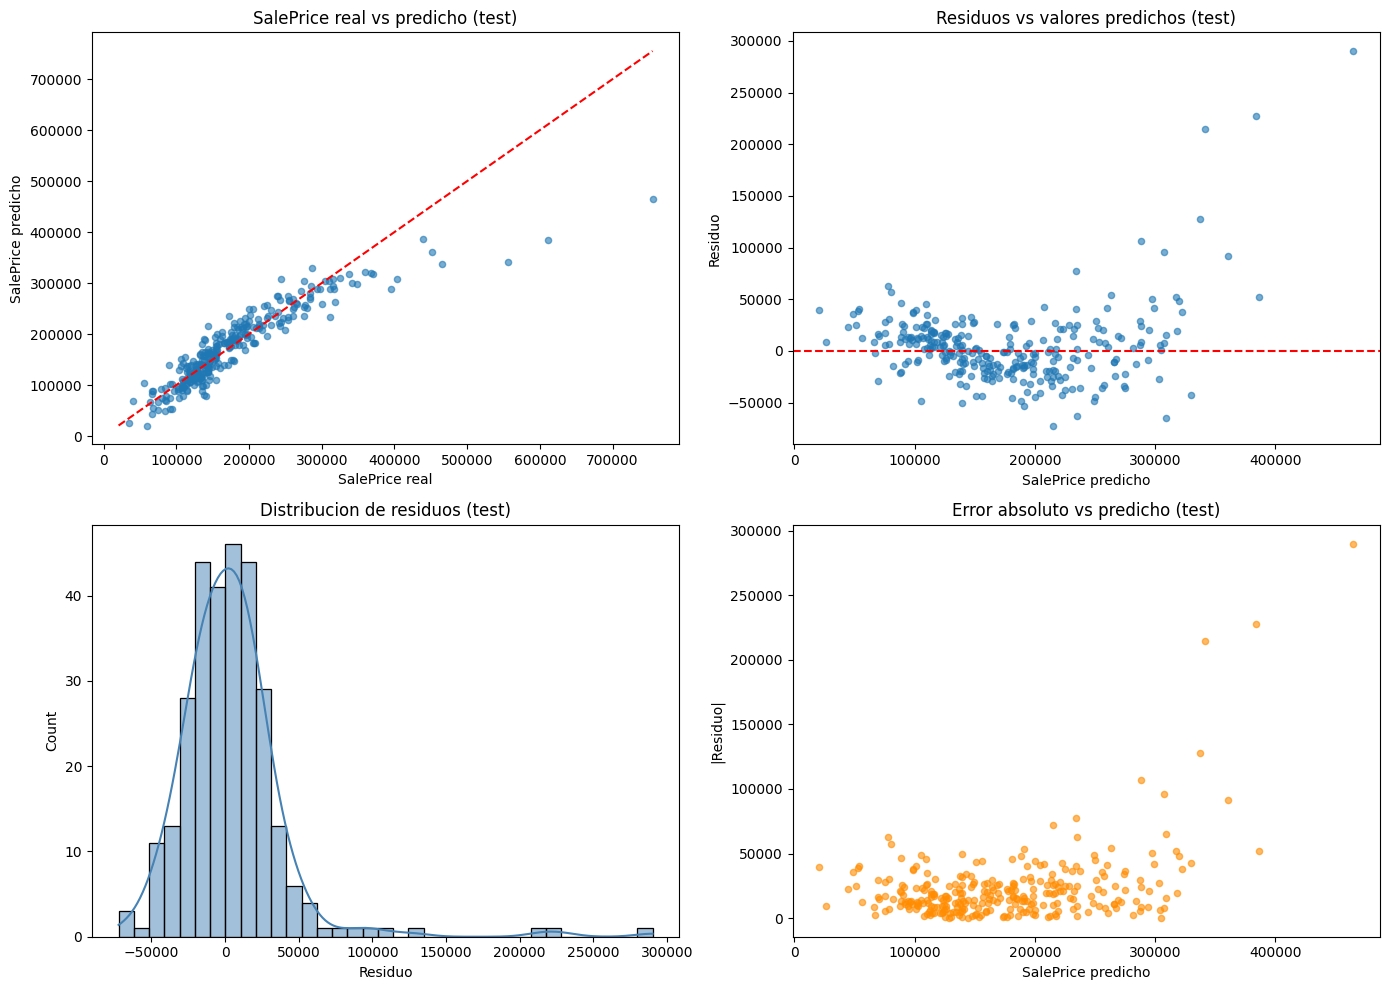

In [10]:
# Analisis grafico del modelo multivariado
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Real vs predicho
axes[0, 0].scatter(y_test_m, y_test_pred_m, alpha=0.6, s=20)
min_v = min(y_test_m.min(), y_test_pred_m.min())
max_v = max(y_test_m.max(), y_test_pred_m.max())
axes[0, 0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 0].set_title('SalePrice real vs predicho (test)')
axes[0, 0].set_xlabel('SalePrice real')
axes[0, 0].set_ylabel('SalePrice predicho')

# 2) Residuos vs predicho
axes[0, 1].scatter(y_test_pred_m, residuos_test_m, alpha=0.6, s=20)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Residuos vs valores predichos (test)')
axes[0, 1].set_xlabel('SalePrice predicho')
axes[0, 1].set_ylabel('Residuo')

# 3) Distribucion de residuos
sns.histplot(residuos_test_m, kde=True, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Distribucion de residuos (test)')
axes[1, 0].set_xlabel('Residuo')

# 4) Error absoluto vs predicho
axes[1, 1].scatter(y_test_pred_m, np.abs(residuos_test_m), alpha=0.6, s=20, color='darkorange')
axes[1, 1].set_title('Error absoluto vs predicho (test)')
axes[1, 1].set_xlabel('SalePrice predicho')
axes[1, 1].set_ylabel('|Residuo|')

plt.tight_layout()
plt.show()

### Conclusión de la Actividad 8

El modelo de regresión lineal múltiple con todas las variables numéricas muestra un desempeño sólido para predecir `SalePrice`, con un $R^2$ de prueba cercano a 0.823. Esto indica que el conjunto de variables numéricas captura gran parte de la variabilidad del precio de las viviendas, superando de forma clara el modelo univariado de la actividad anterior.

El análisis de coeficientes sugiere que la calidad general de la vivienda (`OverallQual`), la capacidad de garaje (`GarageCars`) y características funcionales del hogar tienen un impacto relevante en la predicción. Sin embargo, la interpretación individual de coeficientes debe hacerse con cautela debido a posible multicolinealidad entre variables de tamaño y estructura.

En el diagnóstico de residuos, la mayor concentración ocurre alrededor de 0, pero se observan errores absolutos más altos en propiedades de mayor valor. Por ello, aunque el modelo lineal múltiple es una buena línea base predictiva e interpretable, una mejora futura sería probar regularización (Ridge/Lasso) o modelos no lineales para reducir error en viviendas de precio extremo.